[warn] ignoring unknown args: ['-f', '/pc2/users/h/hpcaljo1/.local/share/jupyter/runtime/kernel-452a9673-9a8d-4a7a-af28-5ca51ae12473.json']
[info] grid=(100,100,1500), h=(0.1,0.1,0.01333), L=(10.0,10.0,20.0)
[info] detector plane at z_det=19.986667 (index k=1499)
[info] loaded selected (new) Ksel=20 with 200000 frames and pool size 20
[pick] mode=random, K=1 → global ids: [2216]
[pick] hit-time stats (selected): mean=26.96, p10=26.96, p50=26.96, p90=26.96
[save] traj_sel_3D.png


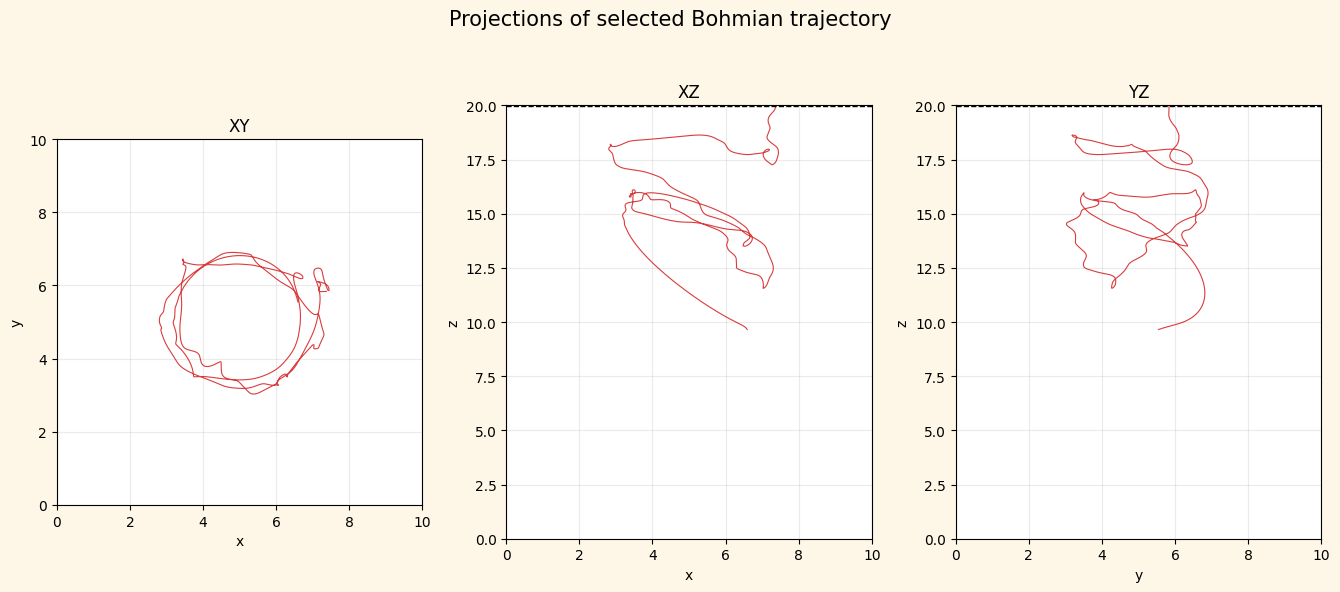

[save] traj_sel_projections.png


In [1]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Pick N trajectories and analyze/plot them.

Supports (priority order):
  1) NEW SELECTED:
     - bohmian_traj_selected.npy (Nsteps, Ksel, 3)
     - bohm_times.npy (Nsteps,)
     - traj_indices.npy (Ksel,)                [optional but recommended]
     - bohm_arrived_mask_selected.npy (Ksel,)  [optional]
     - bohm_t_hit_selected.npy (Ksel,)         [optional]
     If selected-arrival files are missing but FULL arrivals exist,
     we'll map via traj_indices.npy.

  2) OLD SUBSET:
     - traj_subset.npy (Nsnap, K0, 3)
     - traj_subset_times.npy (Nsnap,)
     - traj_subset_idx.npy (K0,)
     - (optional) bohm_arrived_mask.npy (Mpart,), bohm_t_hit.npy (Mpart,)
       (we’ll map using traj_subset_idx.npy)

  3) FULL:
     - bohmian_traj.npy (Nsteps, Mpart, 3)
     - bohm_times.npy (Nsteps,)
     - (optional) bohm_arrived_mask.npy (Mpart,), bohm_t_hit.npy (Mpart,)
"""

from pathlib import Path
import argparse
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import to_rgba

# ---- global plot style: default with white background ----
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "#fef7e7" #"lightgray" "f5f0e6" "fef7e7" "fdf6e3"
plt.rcParams["axes.facecolor"] = "#fef7e7"

# -------------------- args --------------------
p = argparse.ArgumentParser()
p.add_argument("--K", type=int, default=1, help="number of particles to plot/analyze")
p.add_argument("--mode", type=str, default="random",
               choices=["random", "arrived", "unarrived", "earliest", "latest", "spread"],
               help="how to select the K particles")
p.add_argument("--seed", type=int, default=0, help="rng seed for random selection")
args, unknown = p.parse_known_args()
if unknown:
    print(f"[warn] ignoring unknown args: {unknown}")
base = Path(".").resolve()

# -------------------- constants / grid --------------------
C = np.load(base / "constants.npz")
Nx, Ny, Nz = int(C["Nx"]), int(C["Ny"]), int(C["Nz"])
hx, hy, hz = float(C["hx"]), float(C["hy"]), float(C["hz"])
Lx, Ly, Lz = float(C["Lx"]), float(C["Ly"]), float(C["Lz"])
z_det = Lz - hz  # detector ON the grid (matches solver)
print(f"[info] grid=({Nx},{Ny},{Nz}), h=({hx:.4g},{hy:.4g},{hz:.4g}), L=({Lx},{Ly},{Lz})")
print(f"[info] detector plane at z_det={z_det:.6f} (index k={Nz-1})")

# -------------------- arrivals (full or selected; used later) --------------------
arrived_full = None
t_hit_full = None
if (base / "bohm_arrived_mask.npy").exists():
    arrived_full = np.load(base / "bohm_arrived_mask.npy").astype(bool)
if (base / "bohm_t_hit.npy").exists():
    t_hit_full = np.load(base / "bohm_t_hit.npy")

# -------------------- choose data source (NEW selected → OLD subset → FULL) -----
label = ""
idx_map = None  # map from visible-pool indices to global indices (if applicable)

sel_new = (base / "bohmian_traj_selected.npy").exists()
sel_old = (base / "traj_subset.npy").exists()

if sel_new:
    # NEW SELECTED
    TRAJ = np.load(base / "bohmian_traj_selected.npy", mmap_mode="r")  # (Nsteps, Ksel, 3)
    T = np.load(base / "bohm_times.npy") if (base / "bohm_times.npy").exists() else np.arange(TRAJ.shape[0])
    # Optional arrivals aligned with selected order:
    arrived_sel = (np.load(base / "bohm_arrived_mask_selected.npy").astype(bool)
                   if (base / "bohm_arrived_mask_selected.npy").exists() else None)
    t_hit_sel = (np.load(base / "bohm_t_hit_selected.npy")
                 if (base / "bohm_t_hit_selected.npy").exists() else None)
    # Optional global index mapping:
    if (base / "traj_indices.npy").exists():
        idx_map = np.load(base / "traj_indices.npy")  # (Ksel,)
    label = f"selected (new) Ksel={TRAJ.shape[1]}"

    # If selected-arrivals are missing but FULL arrivals exist and idx_map is available, map them:
    if (arrived_sel is None or t_hit_sel is None) and \
       (arrived_full is not None or t_hit_full is not None) and (idx_map is not None):
        if arrived_full is not None:
            arrived_sel = arrived_full[idx_map]
        if t_hit_full is not None:
            t_hit_sel = t_hit_full[idx_map]

    arrived_vis = arrived_sel
    t_hit_vis = t_hit_sel

elif sel_old:
    # OLD SUBSET
    TRAJ = np.load(base / "traj_subset.npy", mmap_mode="r")  # (Nsnap, K0, 3)
    T = np.load(base / "traj_subset_times.npy")              # (Nsnap,)
    idx_map = np.load(base / "traj_subset_idx.npy")          # (K0,)
    label = f"subset (old) K0={TRAJ.shape[1]}"

    arrived_vis = (arrived_full[idx_map] if arrived_full is not None else None)
    t_hit_vis = (t_hit_full[idx_map] if t_hit_full is not None else None)

else:
    # FULL
    full_path = base / "bohmian_traj.npy"
    time_path = base / "bohm_times.npy"
    if not (full_path.exists() and time_path.exists()):
        raise FileNotFoundError(
            "Need one of:\n"
            "  NEW selected: bohmian_traj_selected.npy (+ bohm_times.npy)\n"
            "  OLD subset:   traj_subset.npy + traj_subset_times.npy + traj_subset_idx.npy\n"
            "  FULL:         bohmian_traj.npy + bohm_times.npy"
        )
    TRAJ = np.load(full_path, mmap_mode="r")  # (Nsteps, Mpart, 3)
    T = np.load(time_path)                    # (Nsteps,)
    idx_map = np.arange(TRAJ.shape[1], dtype=int)  # identity
    label = f"full M={TRAJ.shape[1]}"

    arrived_vis = arrived_full
    t_hit_vis = t_hit_full

Nsnap, Mvis = TRAJ.shape[0], TRAJ.shape[1]
print(f"[info] loaded {label} with {Nsnap} frames and pool size {Mvis}")

# -------------------- selection helpers --------------------
rng = np.random.default_rng(args.seed)

def pick_indices(mode: str, K: int) -> np.ndarray:
    pool = np.arange(Mvis)
    # If we lack arrival info, fall back to random
    if arrived_vis is None or t_hit_vis is None:
        if K >= len(pool):
            return pool
        return rng.choice(pool, K, replace=False)

    A = arrived_vis.astype(bool)
    H = t_hit_vis

    if mode == "random":
        return pool if K >= len(pool) else rng.choice(pool, K, replace=False)

    if mode == "arrived":
        cand = np.where(A)[0]
        return cand if K >= cand.size else rng.choice(cand, K, replace=False)

    if mode == "unarrived":
        cand = np.where(~A)[0]
        return cand if K >= cand.size else rng.choice(cand, K, replace=False)

    if mode == "earliest":
        cand = np.where(A & np.isfinite(H))[0]
        if cand.size == 0:
            return np.array([], dtype=int)
        order = np.argsort(H[cand])
        return cand[order[:min(K, cand.size)]]

    if mode == "latest":
        cand = np.where(A & np.isfinite(H))[0]
        if cand.size == 0:
            return np.array([], dtype=int)
        order = np.argsort(H[cand])[::-1]
        return cand[order[:min(K, cand.size)]]

    if mode == "spread":
        cand = np.where(A & np.isfinite(H))[0]
        if cand.size == 0:
            return np.array([], dtype=int)
        q = np.linspace(0.0, 1.0, K, endpoint=False) + 0.5 / K
        qs = np.quantile(H[cand], q)
        sel = []
        used = set()
        for target in qs:
            j = cand[np.argmin(np.abs(H[cand] - target))]
            if j in used:
                pool2 = [x for x in cand if x not in used]
                if not pool2:
                    break
                j = rng.choice(pool2)
            sel.append(j)
            used.add(j)
        return np.array(sel, dtype=int)

    # fallback
    return pool if K >= len(pool) else rng.choice(pool, K, replace=False)

sel = pick_indices(args.mode, args.K)

# Map to global indices (if we know the mapping)
if idx_map is not None:
    global_sel = idx_map[sel]
    print(f"[pick] mode={args.mode}, K={sel.size} → global ids: "
          f"{global_sel[:min(10, sel.size)]}" + (" ..." if sel.size > 10 else ""))
else:
    global_sel = sel
    print(f"[pick] mode={args.mode}, K={sel.size}")

# quick stats
if (t_hit_vis is not None) and (sel.size > 0):
    finite_hits = t_hit_vis[sel][np.isfinite(t_hit_vis[sel])]
    if finite_hits.size > 0:
        print(f"[pick] hit-time stats (selected): mean={finite_hits.mean():.4g}, "
              f"p10={np.percentile(finite_hits, 10):.4g}, "
              f"p50={np.percentile(finite_hits, 50):.4g}, "
              f"p90={np.percentile(finite_hits, 90):.4g}")
    else:
        print("[pick] none of the selected have finite t_hit")

# Slice trajectories down to selected set
XYZ = TRAJ[:, sel, :]   # (Nsnap, K, 3)
X = XYZ[..., 0]
Y = XYZ[..., 1]
Z = XYZ[..., 2]
Tmin, Tmax = T[0], T[-1]

arr_sel = arrived_vis[sel] if arrived_vis is not None else None
hit_sel = t_hit_vis[sel] if t_hit_vis is not None else None

# -------------------- 3D plot --------------------
fig = plt.figure(figsize=(10.0, 10.0))
ax = fig.add_subplot(111, projection="3d")

# ambient background (outside the box)
fig.patch.set_facecolor("#fef7e7")   # same as your rcParams
ax.set_facecolor("#fef7e7")

# make the three panes (inside of the box) pure white and opaque
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor("white")   # pure white
    axis.pane.set_edgecolor("black")   # box edges
    axis.pane.set_alpha(1.0)           # no transparency

# light grid on top of that
ax.grid(True)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    if hasattr(axis, "_axinfo"):
        axis._axinfo["grid"]["linewidth"] = 0.4
        axis._axinfo["grid"]["color"] = (0.6, 0.6, 0.6, 0.25)


# detector rectangle at top (no label → no legend)
xx = np.array([0, Lx, Lx, 0, 0])
yy = np.array([0, 0, Ly, Ly, 0])
zz = np.full_like(xx, z_det)
ax.plot(xx, yy, zz, lw=1.0, alpha=0.3, color="k")   # very soft outline

# trajectories
for j in range(X.shape[1]):
    c = "#d62728" if (arr_sel is not None and arr_sel[j]) else "tab:blue"
    ax.plot(X[:, j], Y[:, j], Z[:, j], lw=0.8, alpha=0.9, color=c)

# axis limits
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.set_zlim(0, Lz)


ax.plot([0, 0], [0, 0], [0, Lz],
        color="gray", lw=1, zorder=10)

# visually widen base
xy_scale = 2.5
z_scale = Lz / max(Lx, Ly)
ax.set_box_aspect((xy_scale, xy_scale, z_scale))

# nice ticks
xticks = [0.0, 0.5 * Lx, Lx]
yticks = [0.0, 0.5 * Ly, Ly]
ax.set_xticks(xticks)
ax.set_yticks(yticks)

fmt = FormatStrFormatter("%.3g")
ax.xaxis.set_major_formatter(fmt)
ax.yaxis.set_major_formatter(fmt)

ax.tick_params(axis="x", labelsize=8, pad=2)
ax.tick_params(axis="y", labelsize=8, pad=2)
ax.tick_params(axis="z", labelsize=10)

ax.set_xlabel("x", labelpad=10)
ax.set_ylabel("y", labelpad=10)
ax.set_zlabel("z")
ax.set_title("One randomly selected Bohmian trajectory", pad=18)


# no title, no legend
# let axes occupy more of the figure → bigger box
fig.subplots_adjust(left=0.14, right=0.86, bottom=0.08, top=0.98)

fig.savefig(base / "traj_sel_3D.png", dpi=220)
plt.close(fig)
print("[save] traj_sel_3D.png")



# -------------------- 2D projections: XY, XZ, YZ --------------------
# make figure a bit taller (second number) so the panels are not so flat
fig, axs = plt.subplots(1, 3, figsize=(13.5, 6.0))

# inside of each panel: white (or very light)
box_bg = "white"          # or "#fef7e7" for a tiny warm tint
for ax2 in axs:
    ax2.set_facecolor(box_bg)


# define colors once
color_arrived   = "#d62728"   # nice strong red
color_unarrived = "tab:blue"  # blue from tab palette

# XY
for j in range(X.shape[1]):
    c = color_arrived if (arr_sel is not None and arr_sel[j]) else color_unarrived
    axs[0].plot(X[:, j], Y[:, j], lw=0.8, alpha=0.9, color=c)

axs[0].set_xlim(0, Lx)
axs[0].set_ylim(0, Ly)
axs[0].set_aspect("equal", adjustable="box")
axs[0].set_title("XY")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].grid(alpha=0.25)

# XZ
for j in range(X.shape[1]):
    c = color_arrived if (arr_sel is not None and arr_sel[j]) else color_unarrived
    axs[1].plot(X[:, j], Z[:, j], lw=0.8, alpha=0.9, color=c)

axs[1].axhline(z_det, ls="--", lw=1.0, color="k")
axs[1].set_xlim(0, Lx)
axs[1].set_ylim(0, Lz)
axs[1].set_title("XZ")
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")
axs[1].grid(alpha=0.25)

# YZ
for j in range(X.shape[1]):
    c = color_arrived if (arr_sel is not None and arr_sel[j]) else color_unarrived
    axs[2].plot(Y[:, j], Z[:, j], lw=0.8, alpha=0.9, color=c)

axs[2].axhline(z_det, ls="--", lw=1.0, color="k")
axs[2].set_xlim(0, Ly)
axs[2].set_ylim(0, Lz)
axs[2].set_title("YZ")
axs[2].set_xlabel("y")
axs[2].set_ylabel("z")
axs[2].grid(alpha=0.25)

# title INSIDE the figure, with room reserved
fig.suptitle("Projections of selected Bohmian trajectory", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])  # leave top 6% for the title
plt.show()
fig.savefig(base / "traj_sel_projections.png", dpi=220)
plt.close(fig)
print("[save] traj_sel_projections.png")


